## 회원 수의 시계열 변화 시뮬레이션

##### **입소문을 통해 스포츠 센터의 이용 상황이 어떻게 변화**해가는지를 시뮬레이션해 봅시다.         
2장에서 다룬 스포츠 센터 분석과 시뮬레이션을 함께 하면 미래를 예측할 수 있습니다           
또 **입소문에 의한 스포츠 센터 회원의 소비자 행동 분석 과정**은 **소비자 행동을 분석하는 과제**라면 어디에나 사용할 수 있는 일반적인 방법입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df_links = pd.read_csv('./4장_data/links.csv', index_col= 0)
df_links.head()

,Node0,Node1,Node2,Node3,Node4,Node5,Node6,Node7,Node8,Node9,Node10,Node11,Node12,Node13,Node14,Node15,Node16,Node17,Node18,Node19
Node0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Node1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
Node2,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Node3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Node4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [6]:
# percent_percolation = 0.1
# percent_disappearance = 0.05

def determine_link(percent) :
  val = np.random.rand()
  if val <= percent :
    return 1
  else :
    return 0

def simulate_population(num, list_activated, df_links, percent_percolation, percent_disappearance) :
  # 확산 : node간 연결을 활용한
  for i in range(num) :
    if list_activated[i] == 1 :
      for j in range(num) :
        if df_links.iloc[i][j] == 1 :
          if determine_link(percent_percolation) == 1 :
            list_activated[j] = 1
  # 소멸 : 모든 노드 중 5%의 확률로 삭제될 가능성 존재
  for i in range(num) :
    if determine_link(percent_disappearance) == 1 :
      list_activated[i] = 0
  return list_activated


> 확산 확률 10%            
> 소멸 확률 5%

In [13]:
percent_percolation = 0.1
percent_disappearance = 0.05
time_series = 100
num = len(df_links)
list_activated = np.zeros(num)
list_activated[0] = 1

list_timeSeries = []
for t in range(time_series) :
  list_activated = simulate_population(num, list_activated, df_links, percent_percolation, percent_disappearance)
  list_timeSeries.append(list_activated.copy())

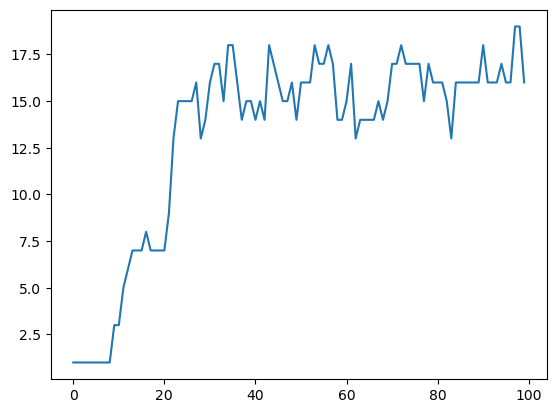

In [14]:
# 시계열 그래프 그리기
list_timeSeries_num = []

for t in range(len(list_timeSeries)) :
  list_timeSeries_num.append(list_timeSeries[t].sum())

# list_timeSeries_num
plt.plot(list_timeSeries_num)
plt.show()


  # 입소문 확산뿐만 아니라 새롭게 '소멸'이라는 조작도 추가합니다
  # 스포츠 센터의 회원은 지금까지 센터를 이용하던 사람이 어느 날 갑자기 이용하지 않는(탈퇴) 경우도 있습니다.
  # 여기서는 그러한 일이 5%의 확률로 일어난다고 가정하고
  # 입소문에 의한 회원 증가와 감소의 모습을 시뮬레이션합니다.
  # 그러면 그림과 같이 증감을 반복하면서 서서히 100%의 이용률을 향해가는 모습을 확인할 있습니다.
  # 전원은 아니지만 커뮤니티의 입소문 힘으로 조금씩 스포츠센터를 이용하는 힘이 강해지는 것으로 보아
  # 현실에 맞는 시뮬레이션 결과라는 것을 알수 있습니다

  # 한편, 소멸의 확률을 조금 늘려보면 이번에는 이용자가 줄어드는 모습을 확인할 수 있습니다.

In [19]:
# 실습)
# 스포츠 센터 회원 입소문 시뮬레이션
def percolation_percentage(percentage) :
  rand_num = np.random.rand()
  if rand_num <= percentage :
    return 1
  else :
    return 0

def simulation_membership_percolation(num, list_activated, df_links, percentage_percolation, percent_disappearance) :
  for i in range(num) :
    if list_activated[i] == 1 :
      for j in range(num) :
        node_nm = 'Node' + str(j)
        if df_links[node_nm].iloc[i] == 1 :
          if percolation_percentage(percentage_percolation) == 1 :
            list_activated[j] = 1

  for i in range(num) :
    if percolation_percentage(percent_disappearance) == 1 :
      list_activated[i] = 0

  return list_activated


In [20]:
t_period = 100
num = len(df_links)
percentage_percolation = 0.1
percentage_disappearance = 0.05
list_activated = np.zeros(num)
list_activated[0] = 1

list_timeSeries = []
for t in range(t_period) :
  list_activated = simulation_membership_percolation(num, list_activated, df_links, percent_percolation, percentage_disappearance)
  list_timeSeries.append(list_activated.copy())


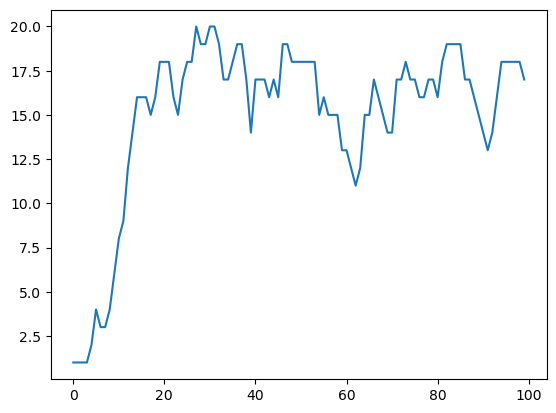

In [21]:
list_timeSeries_num = []
for i in range(len(list_timeSeries)) :
  list_timeSeries_num.append(list_timeSeries[i].sum())

plt.plot(list_timeSeries_num)
plt.show()

# 결국 20명 전원 고객으로 수렴함


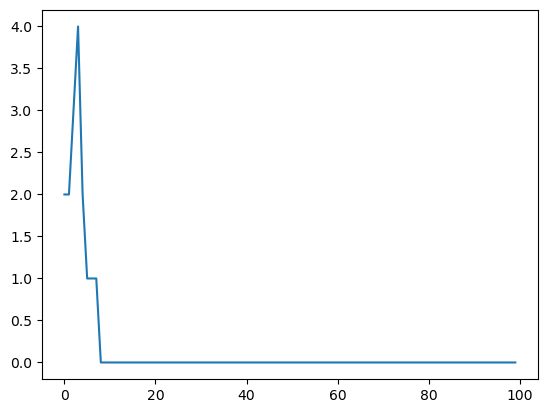

In [25]:
# 소멸의 확률을 조금 늘리면 이용자가 줄어드는 모습을 확인할 수 있습니다.

# 책)

percent_disappearance = 0.2
list_activated = np.zeros(num)
list_activated[0] = 1

list_timeSeries = []
for t in range(t_period) :
  list_activated = simulate_population(num, list_activated, df_links, percent_percolation, percent_disappearance)
  list_timeSeries.append(list_activated.copy())

list_timeSeries_num = []
for i in range(len(list_timeSeries)) :
  list_timeSeries_num.append(list_timeSeries[i].sum())

plt.plot(list_timeSeries_num)
plt.show()

# 반복해서 실행해보면 처음부터 전파 효과보다 소실 효과가 커서 0으로 수렴하기도 하고
# 전파가 더 진행되었다가 0으로 수렴하기도 함
# 현 그래프는 소실될 확률을 20%로 했을때 40개월이면 이용자가 없어짐

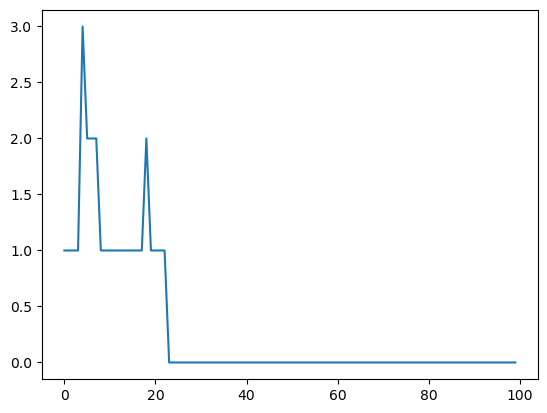

In [26]:
# 소멸의 확률을 조금 늘리면 이용자가 줄어드는 모습을 확인할 수 있습니다.

percent_disappearance = 0.2
list_activated = np.zeros(num)
list_activated[0] = 1

list_timeSeries = []
for t in range(t_period) :
  list_activated = simulation_membership_percolation(num, list_activated, df_links, percent_percolation, percent_disappearance)
  list_timeSeries.append(list_activated.copy())

list_timeSeries_num = []
for i in range(len(list_timeSeries)) :
  list_timeSeries_num.append(list_timeSeries[i].sum())

plt.plot(list_timeSeries_num)
plt.show()

# 반복해서 실행해보면 처음부터 전파 효과보다 소실 효과가 커서 0으로 수렴하기도 하고
# 전파가 더 진행되었다가 0으로 수렴하기도 함
# 현 그래프는 소실될 확률을 20%로 했을때 40개월이면 이용자가 없어짐

## 파라미터 '상관관계'

: 이렇게 입소문 전파(확산)와 이용 중단(소멸)이 **어떤 확률로 일어나는지**는 상품이나 서비스의 성질에 따라 달라지고 캠페인 유무에 따라 영향을 크게 받습니다. 그리고 이 확률이 **상품의 보급에 어떻게 영향을 주는지**(*정착했는지 아니면 잊혀지는지*)가 한층 중요합니다. 이런 보급의 모습을 파악하기 위해서는 '**상관관계**'를 그리면 알기 쉽습니다.

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[20. 19. 19. 18. 17. 16. 16. 17. 14.  9. 12. 11.  7.  9.  0.  0.  0.  0.
  0.  0.]


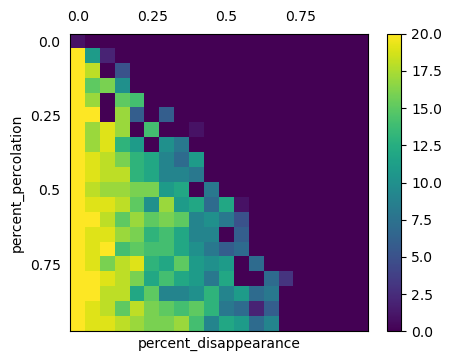

In [27]:
t_period = 100
num_phaseDiagram = 20
phaseDiagram = np.zeros((num_phaseDiagram, num_phaseDiagram))

# phaseDiagram.shape (20, 20)

for i_p in range(num_phaseDiagram) :
  for i_d in range(num_phaseDiagram) :
    percent_percolation = 0.05 * i_p # 0%~95%
    # print(percent_percolation)
    percent_disappearance = 0.05 * i_d # 0%~95%
    list_activated = np.zeros(num)
    list_activated[0] = 1
    for t in range(t_period) :
      list_activated = simulation_membership_percolation(num, list_activated, df_links, percent_percolation, percent_disappearance)
      phaseDiagram[i_p][i_d] = sum(list_activated) # 100개월 동안의 전파 결과(이후 for문 안에서 초기화)
      # [0][0] = 20.0 > (0% 0%)일 때의 확산 정도
      # [0][1] = 15.0 > (0% 5%)일 때의 확산 정도(소멸 확률이 더 큼)
      # [1][0] = 20.0 > (5% 0%)일 때의 확산 정도(확산 확률이 더 큼)

print(phaseDiagram[0])
# 20, 18, 0, 4, (확산 0% & 소멸 확률이 늘어갈 수록 작아짐)
print(phaseDiagram[19])
# 20, 19, 12, (확산 95% & 소멸 확률이 늘어갈 수록 작아지긴 함)

plt.matshow(phaseDiagram)
plt.colorbar(shrink=0.8)
plt.xlabel('percent_disappearance')
plt.ylabel('percent_percolation')
plt.xticks(np.arange(0.0, 20.0, 5), np.arange(0.0, 1.0, 0.25))
plt.yticks(np.arange(0.0, 20.0, 5), np.arange(0.0, 1.0, 0.25))
plt.tick_params(bottom= False,
                left= False,
                right= False,
                top= False)
plt.show()

# 소멸 확률이 0%일 때 20명 전원 확산
# 소멸 확률이 늘어감에 따라 확산 정도가 낮아짐
# 소멸 확률이 20%~30%를 넘어가면 입소문 확률이 아무리 높더라도 이용자는 증가하지 않는 모습


In [ ]:
# 이 결과는 입소문이 일어날 확률과 소멸이 일어날 확률을 조금씩 변화시키면서
# 100개월 후에 몇 명이 계속 이용하는지를 색으로 표시한 것입니다.
# 소멸의 확률이 낮으면 입소문의 확률이 어느 정도 낮아도 탈퇴 없이 20명 전원이 이용하고 있는 것을 볼 수 있습니다.
# 반대로 소멸의 확률이 20~30%를 넘으면 아무리 입소문 확률이 높더라도 이용자는 증가하지 않는 모습을 볼 수 있습니다.
# 이렇게 파라미터의 관계와 성질을 이해하는 데 있어 상관관계 그림이 도움이 됩니다

##  실제 데이터 불러오기

이번에는 스포츠 센터의 회원 전체 데이터를 이용해서 시뮬레이션을 실시해 봅시다   
먼저 540명의 회원 데이터가 있는 links_members.csv와 info_members.csv를 불러옵니다.        
links_members.csv : 540명 각각의 SNS 연결    
info_members.csv : 540명의 24개월간 이용 현황. (이용한 달 : 1, 이용하지 않은 달 : 0)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_mem_links = pd.read_csv("./4장_data/links_members.csv", index_col = 0)
df_mem_links.head()
# 540명의 회원 간 연결 상태(0/1)

df_mem_info = pd.read_csv("./4장_data/info_members.csv", index_col = 0)
df_mem_info.head()
# df_mem_info.info() # 540행 24개열 > 540명의 회원의 24개월 이용현황

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Node0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
Node1,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Node2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Node3,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
Node4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 링크 수의 분포 가시화

앞에서처럼 네트워크를 가시화하는 것이 가장 좋지만 540명이라는 규모는 네트워크를 가시화해도 노드가 밀집해서 네트워크의 상황을 파악하기가 어렵습니다. 네트워크의 구조에는 ***전원이 연결되는 '스몰 월드형'과 소수의 연결을 많이 가지는 사람이 허브가 되는 '스케일 프리형' 등 여러가지***가 있습니다. **어떤 구조를 가지고 있는지는 링크 수의 분포를 가시화**해 보면 어느 정도 파악할 수 있습니다.

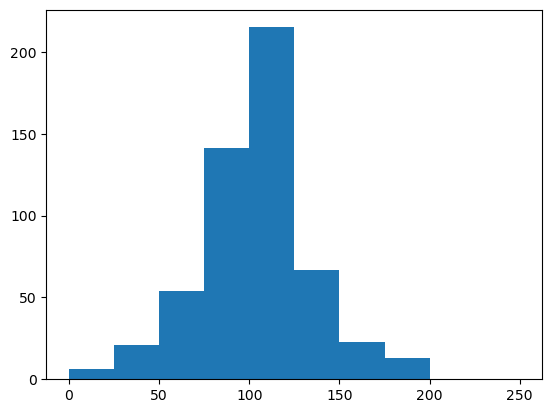

In [ ]:
num = len(df_mem_links)

list_activated_sum = np.zeros(num) # len : 540

for i in range(num) :
  node_nm = 'Node' + str(i)
  list_activated_sum[i] = sum(df_mem_links[node_nm])

len(list_activated_sum) # 540 각 회원별 연결된 노드 수

# 각 회원이 다른 회원과 연결된 정도
plt.hist(list_activated_sum, bins= 10, range= (0, 250))
plt.show()

# 링크 개수의 히스토그램
# 연결된 노드수 중 최대값은 200개 최소값은 0개
# 회원 간 보통 연결된 노드가 100개 정도에 집중된 정규분포에 가까운 모습
# 100개-125개 정도 연결된 빈도가 200을 넘어섬

스케일프리형이라면 이 분포가 '멱 법칙(Power-law Distribution)'에 가까워지며
**링크를 많이 가진 허브**가 ***작동하지 않으면***(입소문을 퍼뜨리지 않으면)
***입소문이 중간에 퍼지지 않는 특징***을 가지고 있습니다.                
그러나 이 분포는 *거의 모든 노드가 어느 정도의 링크 수를 가지고 있는 분포*이기 때문에         
***'급격히 입소문이 퍼지지 않는' 대신에 '허브에 의존하지 않고 입소문이 퍼지기 쉽다'***라고 말할 수 있습니다.


In [ ]:
# 해당 히스토그램을 확인해봤을 때 골고루 분포(허브에만 집중되어 있지 않음)
# >> '급격히 입소문이 퍼지지 않는' 대신 '허브에 의존하지 않고 입소문이 퍼지기 쉽다'

## 실제 데이터로부터 파라미터를 추정

정확도 높은 시뮬레이션을 할 수 있다면 그것을 그대로 미래 예측에 사용할 수 있습니다.        
**시뮬레이션하기 위해서는 먼저 데이터를 이용해서 파라미터를 추정해야 합니다**.            
이번 모델에서 가장 중요한 파라미터는 ***'입소문이 전파될 확률인 'percent_percolation'***과 ***그것이 소멸될 확률인 'percent_disappearance'***입니다.

In [ ]:
df_mem_links.head() # Node0~539 / Node0~539
df_mem_info.head() # 0~23 / Node0~539 > iloc와 컬럼명 동일


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Node0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
Node1,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Node2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Node3,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
Node4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
num = len(df_mem_links) # 540
t_num = len(df_mem_info.columns) # 24
# 전 달과 비교하기 위해서 t vs t+1 (t+1이 23까지만 계산하기 위해)

# 소멸 확률 추정
count_use = 0
count_deactive = 0

for t in range(t_num - 1) : # t_num = 0~22 >> (0,1) ~ (22, 23)
  for i in range(num) : # 0~539
    if (df_mem_info.iloc[i][t] == 1) : # Node'i'가 t월에 이용 실적이 있다면
      count_use += 1
      if (df_mem_info.iloc[i][t+1] == 0) :# t월에 이용했던 Node 'i'가 t+1월에 이용 실적이 없다면
        count_deactive += 1

estimated_percent_disappearance = count_deactive / count_use
print(estimated_percent_disappearance)

# df_mem_info를 시계열 순으로 보고 1스텝 전과 비교해서
# 활성(1)이 비활성(0)으로 변화하는 비율을 세어 추정

0.10147163541419416


In [ ]:
# 확산 확률 추정

count_link= 0
count_link_to_active = 0
=
# ** 이용기록이 있는 회원들이 연결되어 있는 노드 중
# t개월 차 : 기록 0
# t+1개월 차 : 기록 1로 변한 경우로 계산 **

for t in range(t_num - 1) : # t_num = 0~22 >> (0, 1) ~ (22, 23) : df_members_info col명과 동일 / idx와도 동일
  # df_user_t : t개월 차에 사용 기록이 있는 회원들(행/열 : 개월수)
  df_user_t = df_mem_info[df_mem_info[str(t)]== 1]
  temp_flag_count = np.zeros(num) # 540

  # t개월 차에 사용 기록이 있는 개별 회원
  for i in range(len(df_user_t.index)) :
    # df_link_temp : t개월 차 이용한 회원이 연결되어 있는 회원들
    df_link_temp = df_mem_links[df_mem_links[df_user_t.index[i]] == 1]

    # t개월 차 이용한 회원이 연결되어 있는 개별 회원
    for j in range(len(df_link_temp.index)) :
      # t개월 차 이용한 회원이 연결되어 있는 node의 t개월차 이용 기록이 0이라면
      if (df_mem_info[str(t)].loc[df_link_temp.index[j]] == 0) :
        # node 번호에 이미 1이 부과된 경우, count하지 않기 위해
        linked_node_num = int(df_link_temp.index[j].split('Node')[1])
        if (temp_flag_count[linked_node_num] == 0) :
          # link되어 있지만 영향은 주지 않은 case
          count_link += 1
        # t개월 차 이용한 회원이 연결되어 있는 node의 t+1개월차 이용 기록이 1이라면
        if (df_mem_info[str(t+1)].loc[df_link_temp.index[j]] == 1) :
          # node 번호에 이미 1이 부과된 경우, count + 1 하지 않기 위해
          if (temp_flag_count[linked_node_num] == 0) :
            temp_flag_count[linked_node_num] = 1 # 바뀐 경우 flag_count에 해당 노드 번호에 1부여(중복 방지)
            count_link_to_active += 1 # 0인 경우에만 활성화 count + 1

estimated_percent_percolation = count_link_to_active / count_link

# 어떤 노드가 비활성(0)의 상태에서 활성(1)의 상태로 변화했다 합시다.
# 이 노드의 링크 개수와 관계없이
# 단순히 비활성이나 활성의 개수를 세고 그 비율로부터 확률을 추정하는 방법은 정확하지 않습니다.
# 이를 바탕으로 중복해서 세지 않도록 한 것이 위 코드입니다.

In [39]:
print(estimated_percent_percolation)

0.039291643608190374


In [ ]:
# 실습
# 순서
# t 월의 사용 실적이 있는 회원
# t 월의 사용 실적이 있는 회원이 연결된 노드
# t 월의 사용 실적이 있는 회원이 연결된 노드의 t월의 사용 실적
# > 사용 실적이 0이면 count_link += 1
# > 사용 실적이 1이면 count_to_active += 1 & temp_count_flag = 1
# (단, temp_count_flag가 0일때 - 1이면 추가로 부과할 필요 없음)
# temp_count_flag 의 길이 450개로 노드들이 영향을 받은 경우 1이 기록되고 영향 받은 적이 없으면 0이 기록되어 있음


# 비활성화 확률

# 데이터셋)
# df_mem_info # 450명 회원의 24개월 이용 현황
# df_mem_links # 450명 회원 간 연결 상태

count_use = 0
count_unaffected = 0

num = len(df_mem_info.index) # 450
t_num = len(df_mem_info.columns) - 1 # 23 > t+1때문

for i in range(num) :
  for t in range(t_num) : # 0~22 > 마지막 t+1 = 23
    if df_mem_info.iloc[i, t] == 1 : # t월의 이용 실적이 있었다면
      count_use += 1
      if df_mem_info.iloc[i,t + 1] != 1 :
        count_unaffected += 1

percent_disappearance = count_unaffected / count_use
print(percent_disappearance)

# 10.15%

# 확산 확률
# percent_percolation = count_link_to_active / count_link :  링크된 사람 중 실제 활성화된 사람 / 링크된 사람
# + 중복 방지용) temp_count_flag

count_link = 0
count_link_to_active = 0

for t in range(t_num - 1) :
  df_tmonth_user = df_mem_info[df_mem_info[str(t)] == 1] # t month에 이용 실적이 **있는** 회원
  temp_count_flag = np.zeros(num) # 450
  for i in range(len(df_tmonth_user.index)) :
    tmonth_user_nm = df_tmonth_user.index[i]
    df_tmonth_linked = df_mem_links[df_mem_links[tmonth_user_nm] == 1] # t month 이용 회원이 연결(link)된 회원(node)들
    for j in range(len(df_tmonth_linked.index)) : # t month 이용 회원이 연결(link)된 각 회원 node
      tmonth_linked_node = df_tmonth_linked.index[j]
      tmonth_linked_node_num = int(tmonth_linked_node.split('Node')[1])
      if df_mem_info.loc[tmonth_linked_node, str(t)] == 0 : # 연결된 회원이 t month에는 이용 기록이 없고
        if temp_count_flag[tmonth_linked_node_num] == 0 : # 기존에도 1이 아니었다면
          count_link += 1

        if df_mem_info.iloc[tmonth_linked_node_num, t+1] == 1 : # t달은 이용 기록이 0이고 t+1이 1인 경우만 count
          if temp_count_flag[tmonth_linked_node_num] == 0 : # 기존에 1이 아니었다면
            temp_count_flag[tmonth_linked_node_num] = 1 # 1저장
            count_link_to_active += 1

percent_percolation = count_link_to_active / count_link
print(percent_percolation)

# 책과 다른 이유 : 책의 t범위 오류

0.10147163541419416
0.039291643608190374


In [ ]:
percent_percolation = 0.039291643608190374
percent_disappearance = 0.10147163541419416

t_num = 24
num = len(df_mem_links.index) # 회원 수 540
num

list_active = np.zeros(num)
list_active[0] = 1

list_timeSeries = []
for t in range(t_num) :
  list_active = simulation_membership_percolation(num, list_active, df_mem_links, percent_percolation, percent_disappearance)
  list_timeSeries.append(list_active.copy())

540